In [1]:
# [00] Imports

import os, re, json, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
from tqdm.auto import tqdm

In [2]:
# [01] Config

INPUT_ROOT = Path('/kaggle/input')
OUT = Path('/kaggle/working')
CACHE_DIR = OUT / 'cache512'
CACHE_SIZE = 512               # every image is resized (long side) to this, then padded to a square
PAD_COLOR = (124, 116, 104)    # neutral grey used for padding
JPEG_QUALITY = 95              # same re-encode for every source (removes format / EXIF / colour-mode cues)


#   'to_healthy' : label them Healthy      'to_benign' : label them Benign
#   'drop' : leave them out                'keep' : keep as its own class 'Variation'
VARIATION_POLICY = 'to_benign'

# CSV ouputs by four preprocessing notebooks
CSV_NAMES = {
    'smart_om':   'smart_om_merge_ready.csv',
    'piyarathne': 'piyarathne_standardized.csv',
    'zaidpy':     'zaidpy_standardized.csv',
    'shivam':     'standardized_shivam_lips_tongue.csv',
}

# Weight given to labels that nobody clinically verified (used for sampling later)
TIER_WEIGHT = {'clinical_attested': 1.0, 'spot_checked': 1.0, 'uploader_claimed': 0.5}

OUT.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
assert VARIATION_POLICY in ('to_healthy', 'to_benign', 'drop', 'keep')

In [3]:
# [02] Locate the four CSVs

def find_one(name):
    hits = [p for p in INPUT_ROOT.rglob(name) if p.is_file()]
    assert len(hits) >= 1, f'{name} not found under {INPUT_ROOT}. Add the dataset/notebook that contains it'
    if len(hits) > 1:
        print(f'  note: {name} found {len(hits)} times, using {hits[0]}')
    return hits[0]

CSV_PATHS = {k: find_one(v) for k, v in CSV_NAMES.items()}
for k, p in CSV_PATHS.items():
    print(f'{k:<11} {p}')


smart_om    /kaggle/input/notebooks/syedjaffarrazakazmi/smart-om-preprocessing/smart_om_merge_ready.csv
piyarathne  /kaggle/input/notebooks/syedjaffarrazakazmi/01-piyarathne-preprocessing-and-qc-ipynb/piyarathne_standardized.csv
zaidpy      /kaggle/input/notebooks/syedjaffarrazakazmi/cancer-vs-non-cancer-zaid-ipynb/zaidpy_standardized.csv
shivam      /kaggle/input/notebooks/syedjaffarrazakazmi/oc-lips-tongue-shivam/standardized_shivam_lips_tongue.csv


In [4]:
# [03] Load the CSVs and check columns
raw = {k: pd.read_csv(p) for k, p in CSV_PATHS.items()}
for k, d in raw.items():
    print(f'{k:<11} rows={len(d):<5} cols={len(d.columns)}')
print()

# the columns each adapter below relies on
NEEDED = {
    'smart_om':   ['image_id', 'patient_uid', 'id_type', 'orig_label', 'label', 'label_conflict', 'lesion_on_normal',
                   'eval_eligible', 'file_path', 'md5', 'width', 'height'],
    'piyarathne': ['file_name', 'width', 'height', 'Category', 'Clinical Diagnosis', 'patient_id'],
    'zaidpy':     ['file_name', 'file_path', 'image_stem', 'patient_id', 'clinical_condition', 'label_confidence',
                   'width', 'height', 'is_resolution_outlier'],
    'shivam':     ['filepath', 'filename', 'class', 'md5', 'width', 'height', 'likely_web_sourced', 'sample_weight', 'below_224'],
}
for k, cols in NEEDED.items():
    missing = [c for c in cols if c not in raw[k].columns]
    assert not missing, f'{k}: missing columns {missing}'
print('All required columns present.')

smart_om    rows=2442  cols=17
piyarathne  rows=3000  cols=12
zaidpy      rows=724   cols=23
shivam      rows=106   cols=25

All required columns present.


In [5]:
# [04] Adapter: Piyarathne (clinical, real patient IDs)
# Find the folder with the original Piyarathne images. If your Piyarathne notebook output is also attached,
# it holds rotated copies; we prefer the original dataset and fix orientation later, in the cache step.
PIYA_IMG_DIR = None          # set by hand if the search below fails
if PIYA_IMG_DIR is None:
    sample = raw['piyarathne']['file_name'].iloc[0]
    hits = [p.parent for p in INPUT_ROOT.rglob(sample)]
    assert hits, f'Cannot find Piyarathne image {sample}. Add the oca-and-opmd dataset.'
    print(f'Folders that contain {sample}:')
    for h in hits:
        print('  ', h)
    originals = [h for h in hits if '/notebooks/' not in str(h)]
    PIYA_IMG_DIR = (originals or hits)[0]
print('Using:', PIYA_IMG_DIR, '\n')

d = raw['piyarathne']
piya = pd.DataFrame({
    'image_id': 'piyarathne__' + d['image_stem'],
    'source': 'piyarathne',
    'patient_uid': 'piyarathne_' + d['patient_id'].astype(str),
    'id_type': 'real',
    'orig_label': d['Category'],
    'label': d['Category'],                       # already Healthy / Benign / OPMD / OCA
    'detail_label': d['Clinical Diagnosis'],
    'label_tier': 'clinical_attested',
    'src_path': [str(PIYA_IMG_DIR / f) for f in d['file_name']],
    'width': d['width'], 'height': d['height'],   # rotation-corrected size from your Piyarathne notebook
    'eval_ok': True, 'train_ok': True,
    'flag_note': '',
})
assert piya['image_id'].is_unique
print(piya['label'].value_counts().to_string())
print('patients:', piya['patient_uid'].nunique())
print('image files found:', sum(Path(p).exists() for p in piya['src_path']), 'of', len(piya))

Folders that contain R-01-01.jpg:
   /kaggle/input/datasets/syedjaffarrazakazmi/oca-and-opmd/images/Images
   /kaggle/input/notebooks/syedjaffarrazakazmi/01-piyarathne-preprocessing-and-qc-ipynb/piyarathne/images
Using: /kaggle/input/datasets/syedjaffarrazakazmi/oca-and-opmd/images/Images 

label
OPMD       1394
Benign      748
Healthy     729
OCA         129
patients: 714
image files found: 3000 of 3000


In [6]:
# [05] Adapter: SMART-OM (clinical, real patient IDs, label conflicts flagged)
d = raw['smart_om']
smart = pd.DataFrame({
    'image_id': d['image_id'],
    'source': 'smart_om',
    'patient_uid': d['patient_uid'],
    'id_type': d['id_type'],                      # 'real', or 'assumed' for the Ca N cases
    'orig_label': d['orig_label'],
    'label': d['label'],                          # Healthy / Variation / OPMD / OCA
    'detail_label': d['orig_label'],
    'label_tier': 'clinical_attested',
    'src_path': d['file_path'],
    'md5_src': d['md5'],                          # used later to confirm we opened the right file
    'width': d['width'], 'height': d['height'],
    'eval_ok': d['eval_eligible'].astype(bool),   # False for label conflicts and lesion_on_normal
    'train_ok': ~d['label_conflict'].astype(bool),# photos filed under 2 classes: true label unknown
    'flag_note': np.where(d['label_conflict'], 'label_conflict',
                          np.where(d['lesion_on_normal'], 'lesion_on_normal', '')),
})
assert smart['image_id'].is_unique
print(smart['label'].value_counts().to_string())
print('patients:', smart['patient_uid'].nunique())
print('train_ok False:', int((~smart['train_ok']).sum()), '| eval_ok False:', int((~smart['eval_ok']).sum()))

label
Healthy      2119
Variation     178
OPMD          125
OCA            20
patients: 329
train_ok False: 27 | eval_ok False: 31


In [7]:
# [06] Adapter: zaidpy (web/uploader labels, synthetic case IDs, never used for validation or test)
d = raw['zaidpy']
zmap = {'04. Oral Cancer': 'OCA', '01. Normal': 'Healthy'}
zaid = pd.DataFrame({
    'image_id': 'zaidpy__' + d['clinical_condition'].str[:2] + '__' + d['image_stem'].astype(str),
    'source': 'zaidpy',
    'patient_uid': d['patient_id'].astype(str),   # ZAIDPY_CASE_<n>: near-duplicates share one ID
    'id_type': 'synthetic_near_dup',
    'orig_label': d['clinical_condition'],
    'label': d['clinical_condition'].map(zmap),
    'detail_label': d['clinical_condition'],
    'label_tier': d['label_confidence'].map({'unverified_uploader_label': 'uploader_claimed',
                                             'visually_spot_checked_healthy': 'spot_checked'}),
    'src_path': d['file_path'],
    'width': d['width'], 'height': d['height'],
    'eval_ok': False,                             # unverified labels and web images: training only
    'train_ok': True,
    'flag_note': np.where(d['is_resolution_outlier'], 'resolution_outlier', ''),
})
assert zaid['label'].notna().all() and zaid['label_tier'].notna().all()
assert zaid['image_id'].is_unique
print(zaid['label'].value_counts().to_string())
print(zaid['label_tier'].value_counts().to_string())
print('case groups:', zaid['patient_uid'].nunique(), '| resolution outliers:', int((zaid['flag_note'] == 'resolution_outlier').sum()))

label
OCA        478
Healthy    246
label_tier
uploader_claimed    478
spot_checked        246
case groups: 700 | resolution outliers: 7


In [8]:
# [07] Adapter: shivam (web + phone photos, image-level, never used for validation or test)
d = raw['shivam']
shiv = pd.DataFrame({
    'image_id': 'shivam__' + d['md5'].str[:16],
    'source': 'shivam',
    'patient_uid': 'shivam_' + d['md5'].str[:16],   # no patient info: one ID per image (near-duplicates are merged later)
    'id_type': 'image_level',
    'orig_label': d['class'],
    'label': d['class'].map({'cancer': 'OCA', 'non-cancer': 'Healthy'}),
    'detail_label': d['class'],
    'label_tier': 'uploader_claimed',
    'src_path': d['filepath'],
    'md5_src': d['md5'],
    'width': d['width'], 'height': d['height'],
    'eval_ok': False,
    'train_ok': True,
    'flag_note': np.where(d['likely_web_sourced'], 'web_sourced', ''),
})
shiv['shivam_weight'] = d['sample_weight'].values   # 0.5 for web-sourced cancer images, 1.0 otherwise
assert shiv['label'].notna().all()
assert shiv['image_id'].is_unique
print(shiv['label'].value_counts().to_string())
print()
print(pd.crosstab(shiv['label'], [shiv['flag_note'].replace('', 'camera'), shiv['shivam_weight']]).to_string())

label
OCA        63
Healthy    43

flag_note     camera web_sourced    
shivam_weight    1.0         0.5 1.0
label                               
Healthy           26           0  17
OCA                2          61   0


In [9]:
# [08] Combine the four sources and apply the Variation policy
manifest = pd.concat([piya, smart, zaid, shiv], ignore_index=True)

# --- SMART-OM 'Variation from normal' policy (set in cell [01]) ---
n_var = int((manifest['label'] == 'Variation').sum())
if VARIATION_POLICY == 'to_healthy':
    manifest['label'] = manifest['label'].replace({'Variation': 'Healthy'})
elif VARIATION_POLICY == 'to_benign':
    manifest['label'] = manifest['label'].replace({'Variation': 'Benign'})
elif VARIATION_POLICY == 'drop':
    manifest = manifest[manifest['label'] != 'Variation'].copy()
print(f'Variation photos: {n_var} -> policy {VARIATION_POLICY!r}')

# Mark SMART-OM Variation photos, so Part B can report them as a separate slice (they keep orig_label too)
manifest['is_variation'] = (manifest['source'] == 'smart_om') & manifest['orig_label'].str.contains('Variation', na=False)

# --- weights: from the label tier, except shivam which keeps the weight from its own notebook ---
manifest['base_weight'] = manifest['label_tier'].map(TIER_WEIGHT)
mask = manifest['source'] == 'shivam'
manifest.loc[mask, 'base_weight'] = manifest.loc[mask, 'shivam_weight']
manifest = manifest.drop(columns=['shivam_weight']).reset_index(drop=True)

assert manifest['image_id'].is_unique, 'image_id is not unique'
assert manifest['label'].notna().all()
assert manifest['base_weight'].notna().all()

print('\nTotal rows:', len(manifest))
print(manifest['label'].value_counts().to_string())
print('\nWeights by source and tier:')
print(manifest.groupby(['source', 'label_tier'])['base_weight'].agg(['count', 'mean']).round(3).to_string())

Variation photos: 178 -> policy 'to_benign'

Total rows: 6272
label
Healthy    3137
OPMD       1519
Benign      926
OCA         690

Weights by source and tier:
                              count   mean
source     label_tier                     
piyarathne clinical_attested   3000  1.000
shivam     uploader_claimed     106  0.712
smart_om   clinical_attested   2442  1.000
zaidpy     spot_checked         246  1.000
           uploader_claimed     478  0.500


In [10]:
# [09] Check the image files exist (and repair paths if a dataset is mounted somewhere else)
manifest['src_exists'] = manifest['src_path'].map(lambda p: Path(p).exists())
n_missing = int((~manifest['src_exists']).sum())
print('Missing before repair:', n_missing)

if n_missing:
    # Index every image under /kaggle/input by file name, then match on the last path parts
    exts = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
    by_name = {}
    for p in tqdm(INPUT_ROOT.rglob('*'), desc='index input files'):
        if p.suffix.lower() in exts:
            by_name.setdefault(p.name, []).append(p)

    def repair(orig):
        orig = Path(orig)
        cands = by_name.get(orig.name, [])
        def score(c):                      # how many trailing path parts agree
            a, b = c.parts[::-1], orig.parts[::-1]
            k = 0
            while k < min(len(a), len(b)) and a[k] == b[k]:
                k += 1
            return k
        scored = sorted(((score(c), str(c)) for c in cands), reverse=True)
        if scored and scored[0][0] >= 2 and (len(scored) == 1 or scored[0][0] > scored[1][0]):
            return scored[0][1]
        return None

    fixed = 0
    for idx in manifest.index[~manifest['src_exists']]:
        new = repair(manifest.at[idx, 'src_path'])
        if new:
            manifest.at[idx, 'src_path'] = new
            manifest.at[idx, 'src_exists'] = True
            fixed += 1
    print('Repaired paths:', fixed)

print(manifest.groupby('source')['src_exists'].agg(['sum', 'size']).rename(columns={'sum': 'found', 'size': 'rows'}))
missing = manifest[~manifest['src_exists']]
if len(missing):
    print('Example missing paths:')
    print(missing[['source', 'src_path']].head(5).to_string(index=False))
assert not len(missing), 'Some image files are missing. Attach the matching raw dataset (see the inputs table).'

Missing before repair: 0
            found  rows
source                 
piyarathne   3000  3000
shivam        106   106
smart_om     2442  2442
zaidpy        724   724


In [11]:
# [10] Verify file contents with md5
# SMART-OM and shivam store each photo's md5 in their CSV. Confirm we opened exactly that file
# (this catches opening a resized stage copy or the wrong file instead of the plain photo).
def md5_file(p, chunk=1 << 20):
    h = hashlib.md5()
    with open(p, 'rb') as f:
        for b in iter(lambda: f.read(chunk), b''):
            h.update(b)
    return h.hexdigest()

chk = manifest[manifest['md5_src'].notna()]
mism = [r.image_id for r in tqdm(chk.itertuples(), total=len(chk), desc='md5 check') if md5_file(r.src_path) != r.md5_src]
print('Files checked:', len(chk), '| md5 mismatches:', len(mism))
assert not mism, f'md5 mismatch for {mism[:5]}: the file on disk is not the photo the CSV describes'

md5 check:   0%|          | 0/2548 [00:00<?, ?it/s]

Files checked: 2548 | md5 mismatches: 0


In [12]:
# [11] Audit tables: which source supplies which label?
# Read these before moving on. If one label comes mostly from one source, a model can learn the source instead of the disease.
print('Photos per source and label')
print(pd.crosstab(manifest['source'], manifest['label'], margins=True).to_string())

print('\nShare of each label that comes from each source')
print(pd.crosstab(manifest['source'], manifest['label'], normalize='columns').round(2).to_string())

print('\nPatient groups per source and label')
print(manifest.groupby(['source', 'label'])['patient_uid'].nunique().unstack(fill_value=0).to_string())

print('\nLabel tier by label')
print(pd.crosstab(manifest['label'], manifest['label_tier']).to_string())

print('\nAllowed for validation/test (eval_ok):', int(manifest['eval_ok'].sum()),
      '| allowed for training (train_ok):', int(manifest['train_ok'].sum()))
print(pd.crosstab(manifest['label'], manifest['eval_ok'], rownames=['label'], colnames=['eval_ok']).to_string())

Photos per source and label
label       Benign  Healthy  OCA  OPMD   All
source                                      
piyarathne     748      729  129  1394  3000
shivam           0       43   63     0   106
smart_om       178     2119   20   125  2442
zaidpy           0      246  478     0   724
All            926     3137  690  1519  6272

Share of each label that comes from each source
label       Benign  Healthy   OCA  OPMD
source                                 
piyarathne    0.81     0.23  0.19  0.92
shivam        0.00     0.01  0.09  0.00
smart_om      0.19     0.68  0.03  0.08
zaidpy        0.00     0.08  0.69  0.00

Patient groups per source and label
label       Benign  Healthy  OCA  OPMD
source                                
piyarathne     273      259   61   332
shivam           0       43   63     0
smart_om       110      306   18    64
zaidpy           0      231  469     0

Label tier by label
label_tier  clinical_attested  spot_checked  uploader_claimed
label         

In [13]:
# [12] Image normalisation function
# Every image goes through the same steps, so file format, EXIF and colour mode cannot hint at the source:
#   1. fix orientation from EXIF   2. flatten transparency onto white, convert to RGB (drops all metadata)
#   3. resize the long side to CACHE_SIZE, pad to a square with grey
def normalise_image(path, expect_wh=None):
    """Returns (PIL image of CACHE_SIZE x CACHE_SIZE, note). expect_wh is only used for Piyarathne."""
    with Image.open(path) as im:
        im.load()
        orient = im.getexif().get(0x0112, 1)          # EXIF orientation tag (1 = normal)
        im = ImageOps.exif_transpose(im)
        note = 'ok' if orient in (None, 0, 1) else f'exif_{orient}'

        # Piyarathne only: your notebook rotated some images 90 degrees so the boxes fit.
        # If EXIF did not already explain a size difference, apply the same rotation.
        if expect_wh is not None and im.size != tuple(expect_wh):
            if orient in (None, 0, 1) and im.size == tuple(expect_wh)[::-1] and im.size[0] != im.size[1]:
                im = im.rotate(90, expand=True)
                note = 'rotated90_to_match_csv'
            else:
                note = 'size_mismatch_with_csv' if orient in (None, 0, 1) else 'exif_size_mismatch'

        # transparency -> white background, everything else -> RGB
        if im.mode in ('RGBA', 'LA') or (im.mode == 'P' and 'transparency' in im.info):
            im = im.convert('RGBA')
            bg = Image.new('RGB', im.size, (255, 255, 255))
            bg.paste(im, mask=im.split()[-1])
            im = bg
        else:
            im = im.convert('RGB')

    w, h = im.size
    s = CACHE_SIZE / max(w, h)
    im = im.resize((max(1, round(w * s)), max(1, round(h * s))), Image.LANCZOS)
    canvas = Image.new('RGB', (CACHE_SIZE, CACHE_SIZE), PAD_COLOR)
    canvas.paste(im, ((CACHE_SIZE - im.size[0]) // 2, (CACHE_SIZE - im.size[1]) // 2))
    return canvas, note

In [14]:
# [13] Build the image cache (slow cell: about 10 to 20 minutes, mostly the large Piyarathne photos)
# Safe to rerun: images already in the cache are skipped, and their notes are read back from cache_notes.csv.
import time
notes_file = OUT / 'cache_notes.csv'
old_notes = dict(pd.read_csv(notes_file).values) if notes_file.exists() else {}

cache_paths, notes, errors = [], [], []
t0 = time.time()
for r in tqdm(manifest.itertuples(index=False), total=len(manifest), desc='cache'):
    out_path = CACHE_DIR / f'{r.image_id}.jpg'
    exp = (r.width, r.height) if r.source == 'piyarathne' else None
    try:
        if out_path.exists():
            note = old_notes.get(r.image_id, 'cached')
        else:
            img, note = normalise_image(r.src_path, exp)
            img.save(out_path, format='JPEG', quality=JPEG_QUALITY, subsampling=0)
        cache_paths.append(str(out_path)); notes.append(note); errors.append('')
    except Exception as e:
        cache_paths.append(''); notes.append('error'); errors.append(f'{type(e).__name__}: {e}')

manifest['cache_path'] = cache_paths
manifest['cache_note'] = notes
manifest['cache_error'] = errors
manifest[['image_id', 'cache_note']].to_csv(notes_file, index=False)

print(f'Done in {(time.time() - t0) / 60:.1f} minutes')
print('\nCache notes by source:')
print(pd.crosstab(manifest['source'], manifest['cache_note']).to_string())
print('\nErrors:', int((manifest['cache_error'] != '').sum()))

cache:   0%|          | 0/6272 [00:00<?, ?it/s]

Done in 21.7 minutes

Cache notes by source:
cache_note  error  exif_3  exif_6  exif_8    ok
source                                         
piyarathne      1       2     140       3  2854
shivam          0       0       0       0   106
smart_om        0       0       0       0  2442
zaidpy          0       0      14       0   710

Errors: 1


In [15]:
# [13b] Show the image that failed
bad = manifest[manifest['cache_error'] != '']
print(bad[['image_id', 'source', 'src_path', 'width', 'height', 'cache_error']].to_string(index=False))

            image_id     source                                                                           src_path  width  height                                               cache_error
piyarathne__N-260-01 piyarathne /kaggle/input/datasets/syedjaffarrazakazmi/oca-and-opmd/images/Images/N-260-01.jpg   2448    3264 OSError: image file is truncated (30 bytes not processed)


piyarathne__N-260-01 -> ok | label: OPMD
Errors left: 0 | eval_ok now: 5410


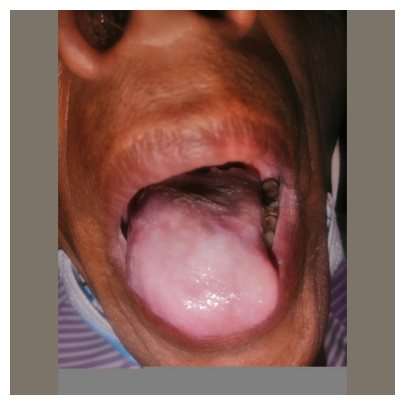

In [16]:
# [13b] Rescue the truncated image
# The file is missing its last 30 bytes. PIL can still decode almost all of it if we allow truncated files.
from PIL import ImageFile
import matplotlib.pyplot as plt

ImageFile.LOAD_TRUNCATED_IMAGES = True
bad_idx = manifest.index[manifest['cache_error'] != '']
for i in bad_idx:
    r = manifest.loc[i]
    exp = (r['width'], r['height']) if r['source'] == 'piyarathne' else None
    img, note = normalise_image(r['src_path'], exp)
    out_path = CACHE_DIR / f"{r['image_id']}.jpg"
    img.save(out_path, format='JPEG', quality=JPEG_QUALITY, subsampling=0)
    manifest.loc[i, ['cache_path', 'cache_note', 'cache_error']] = [str(out_path), note + '+truncated', '']
    manifest.loc[i, 'flag_note'] = 'truncated_file'
    manifest.loc[i, 'eval_ok'] = False       # keep this one photo out of validation and test
    print(r['image_id'], '->', note, '| label:', r['label'])
ImageFile.LOAD_TRUNCATED_IMAGES = False

manifest[['image_id', 'cache_note']].to_csv(OUT / 'cache_notes.csv', index=False)
print('Errors left:', int((manifest['cache_error'] != '').sum()), '| eval_ok now:', int(manifest['eval_ok'].sum()))

# Look at it: a truncated JPEG usually shows a grey or smeared strip at the bottom
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(Image.open(manifest.loc[bad_idx[0], 'cache_path']))
ax.axis('off')
plt.show()

In [17]:
# [14] Verify the cache
# 1) every cached file exists
missing_files = [p for p in manifest['cache_path'] if not Path(p).exists()]
print('Cached files:', len(manifest) - len(missing_files), 'of', len(manifest))
assert not missing_files, 'Some cached files are missing, rerun cell [13]'

# 2) every file is exactly CACHE_SIZE x CACHE_SIZE
def size_of(p):
    with Image.open(p) as im:
        return im.size
bad_size = [p for p in tqdm(manifest['cache_path'], desc='sizes') if size_of(p) != (CACHE_SIZE, CACHE_SIZE)]
print('Wrong size:', len(bad_size))
assert not bad_size

# 3) Piyarathne images whose size we could not explain
unexplained = manifest['cache_note'].str.contains('size_mismatch').sum()
print('Piyarathne size mismatches after fixes:', int(unexplained))

# 4) near-constant images (blank, black, failed decode) and average brightness per source
def small_stats(p):
    with Image.open(p) as im:
        a = np.asarray(im.convert('L').resize((64, 64)), dtype=np.float32)
    return a.mean(), a.std()
stats = [small_stats(p) for p in tqdm(manifest['cache_path'], desc='pixel stats')]
manifest['img_mean'] = [s[0] for s in stats]
manifest['img_std'] = [s[1] for s in stats]

flat = manifest[manifest['img_std'] < 5]
print('\nNear-constant images (std < 5):', len(flat))
if len(flat):
    print(flat[['image_id', 'source', 'label', 'img_mean', 'img_std']].head(10).to_string(index=False))

print('\nAverage brightness (0-255) by source and label')
print(manifest.groupby(['source', 'label'])['img_mean'].mean().round(0).unstack().to_string())

Cached files: 6272 of 6272


sizes:   0%|          | 0/6272 [00:00<?, ?it/s]

Wrong size: 0
Piyarathne size mismatches after fixes: 0


pixel stats:   0%|          | 0/6272 [00:00<?, ?it/s]


Near-constant images (std < 5): 0

Average brightness (0-255) by source and label
label       Benign  Healthy    OCA   OPMD
source                                   
piyarathne   108.0    105.0  108.0  107.0
shivam         NaN    123.0  126.0    NaN
smart_om     124.0    131.0  123.0  119.0
zaidpy         NaN    133.0  124.0    NaN


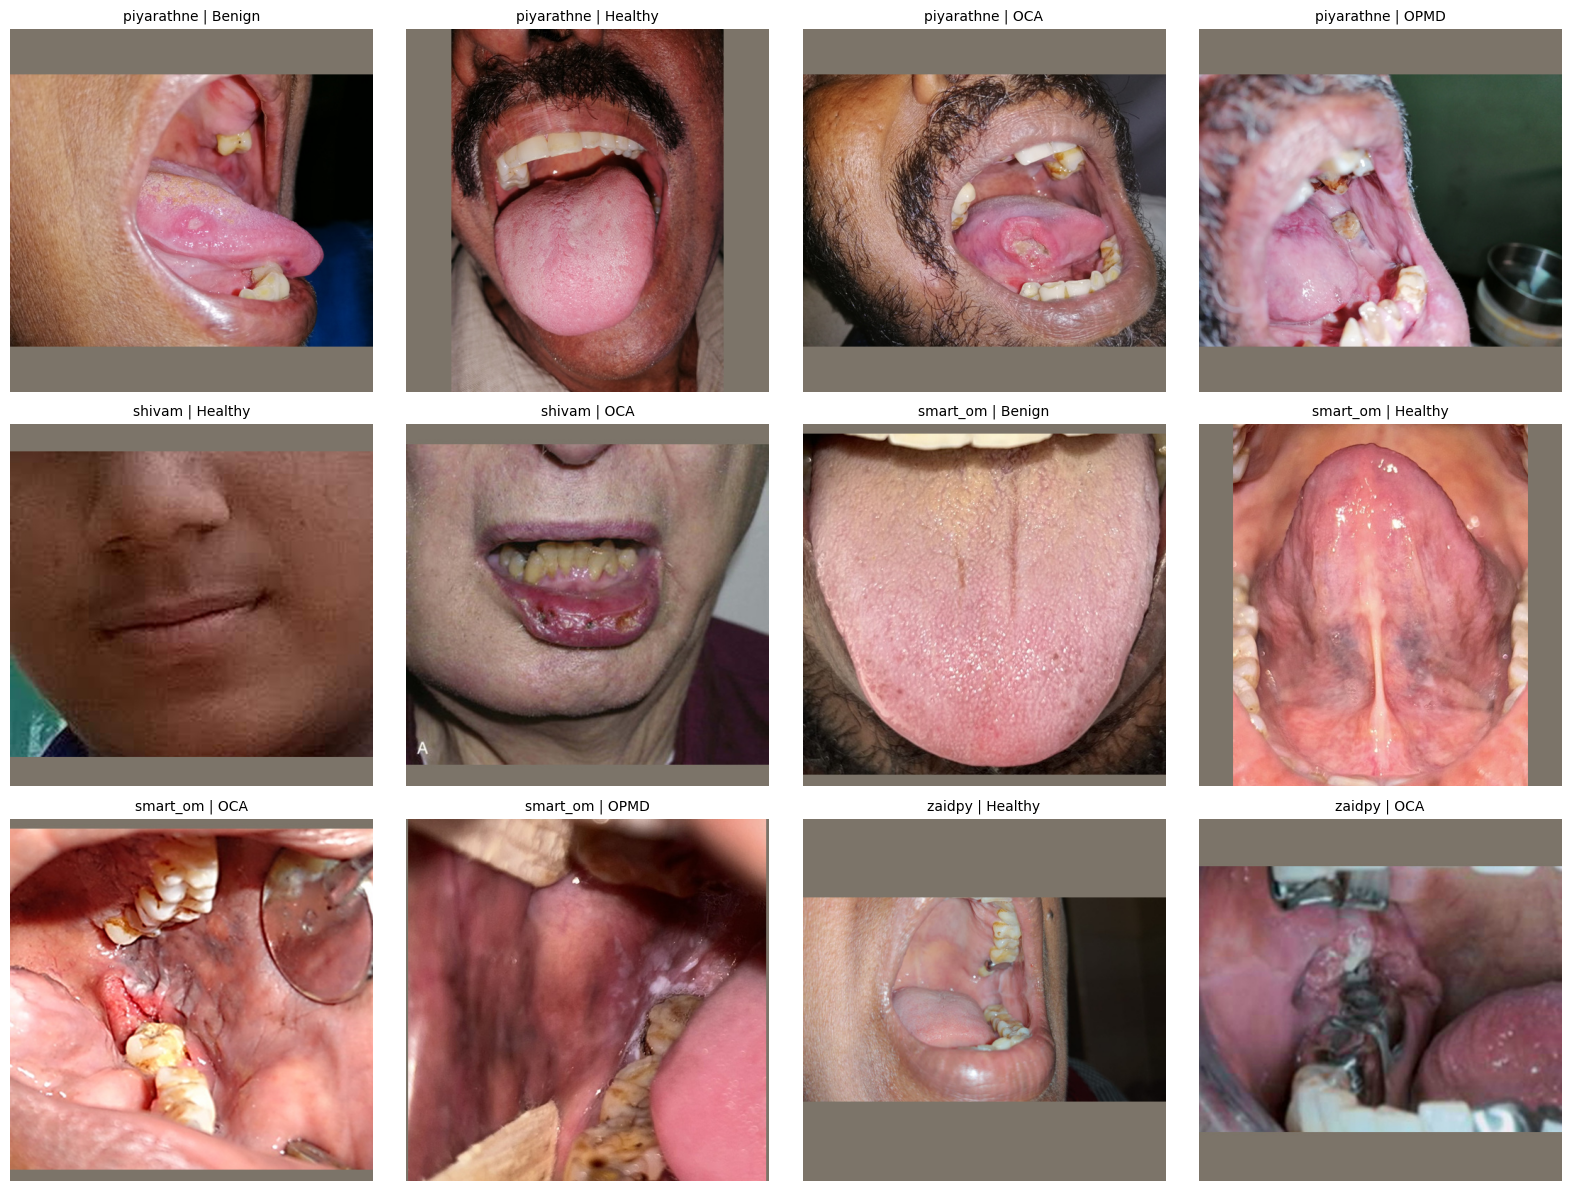

In [18]:
# [15] Visual check: one random cached image for every source and label
import matplotlib.pyplot as plt

picks = []
for src in sorted(manifest['source'].unique()):
    for lab in sorted(manifest.loc[manifest['source'] == src, 'label'].unique()):
        sub = manifest[(manifest['source'] == src) & (manifest['label'] == lab)]
        picks.append(sub.sample(1, random_state=0).iloc[0])

cols = 4
nrows = (len(picks) + cols - 1) // cols
fig, axes = plt.subplots(nrows, cols, figsize=(4 * cols, 4 * nrows))
for ax in axes.flat:
    ax.axis('off')
for ax, r in zip(axes.flat, picks):
    with Image.open(r['cache_path']) as im:
        ax.imshow(im.copy())
    ax.set_title(f"{r['source']} | {r['label']}", fontsize=10)
plt.tight_layout()
plt.show()

In [19]:
# [16] Save manifest_raw.csv and a summary
manifest['cache_file'] = manifest['image_id'] + '.jpg'     # file name inside cache512/ (Part B finds the folder itself)

keep = ['image_id', 'source', 'patient_uid', 'id_type', 'orig_label', 'detail_label', 'label', 'label_tier',
        'base_weight', 'eval_ok', 'train_ok', 'is_variation', 'flag_note', 'width', 'height',
        'src_path', 'cache_file', 'cache_note', 'img_mean', 'img_std']
manifest[keep].to_csv(OUT / 'manifest_raw.csv', index=False)

cache_gb = sum(p.stat().st_size for p in CACHE_DIR.glob('*.jpg')) / 1e9
summary = {
    'rows': int(len(manifest)),
    'rows_per_source': manifest['source'].value_counts().to_dict(),
    'rows_per_label': manifest['label'].value_counts().to_dict(),
    'variation_policy': VARIATION_POLICY,
    'cache_size': CACHE_SIZE, 'jpeg_quality': JPEG_QUALITY, 'cache_gb': round(cache_gb, 2),
    'eval_ok': int(manifest['eval_ok'].sum()), 'train_ok': int(manifest['train_ok'].sum()),
    'truncated_files': int(manifest['cache_note'].str.contains('truncated').sum()),
}
with open(OUT / 'merge_part_a_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

n_cached = len(list(CACHE_DIR.glob('*.jpg')))
print(f'\nSaved: manifest_raw.csv ({len(manifest)} rows), merge_part_a_summary.json, cache512/ ({n_cached} images, {cache_gb:.2f} GB)')

{
  "rows": 6272,
  "rows_per_source": {
    "piyarathne": 3000,
    "smart_om": 2442,
    "zaidpy": 724,
    "shivam": 106
  },
  "rows_per_label": {
    "Healthy": 3137,
    "OPMD": 1519,
    "Benign": 926,
    "OCA": 690
  },
  "variation_policy": "to_benign",
  "cache_size": 512,
  "jpeg_quality": 95,
  "cache_gb": 0.46,
  "eval_ok": 5410,
  "train_ok": 6245,
  "truncated_files": 1
}

Saved: manifest_raw.csv (6272 rows), merge_part_a_summary.json, cache512/ (6272 images, 0.46 GB)
